In [19]:
import glob
import json
import os
import pandas as pd

hasil = []

for file in sorted(glob.glob('*.ipynb')):
  if 'Perbandingan' in file:
    continue

  with open(file, 'r', encoding='utf-8') as f:
    nb = json.load(f)

  for cell in nb['cells']:
    for out in cell.get('outputs', []):
      txt = ''.join(out.get('text', []))
      if 'HASIL PENGUJIAN' in txt:

        baris = [
            l.split(':')[1].strip()
            for l in txt.splitlines()
            if l.strip()[:2] in ['1.', '2.', '3.', '4.']
        ]

        hasil.append({
            'Model': os.path.basename(file).replace('.ipynb', ''),
            'Klaster': int(baris[0].split()[0]),
            'Noise': (
                int(baris[0].split('dan ')[1].split()[0])
                if 'dan ' in baris[0]
                else 0
            ),
            'Waktu (s)': float(baris[1].split()[0]),
            'Silhouette': float(baris[2].split()[0]),
            'Memori (MB)': float(baris[3].split()[0]),
        })

df_master = pd.DataFrame(hasil)
df_master

,Model,Klaster,Noise,Waktu (s),Silhouette,Memori (MB)
0,DBScan_Cosine,2,59,0.2381,0.0035,333.32
1,DBScan_Euclidean,2,59,0.1886,0.0022,266.86
2,DBScan_Manhattan,2,919,0.2870,0.1862,2.22
3,K-Means_Cosine,6,0,0.1777,0.0524,1.72
4,K-Means_Euclidean,6,0,0.1743,0.0011,1.72
5,K-Means_Manhattan,7,0,0.2274,0.0127,1.75


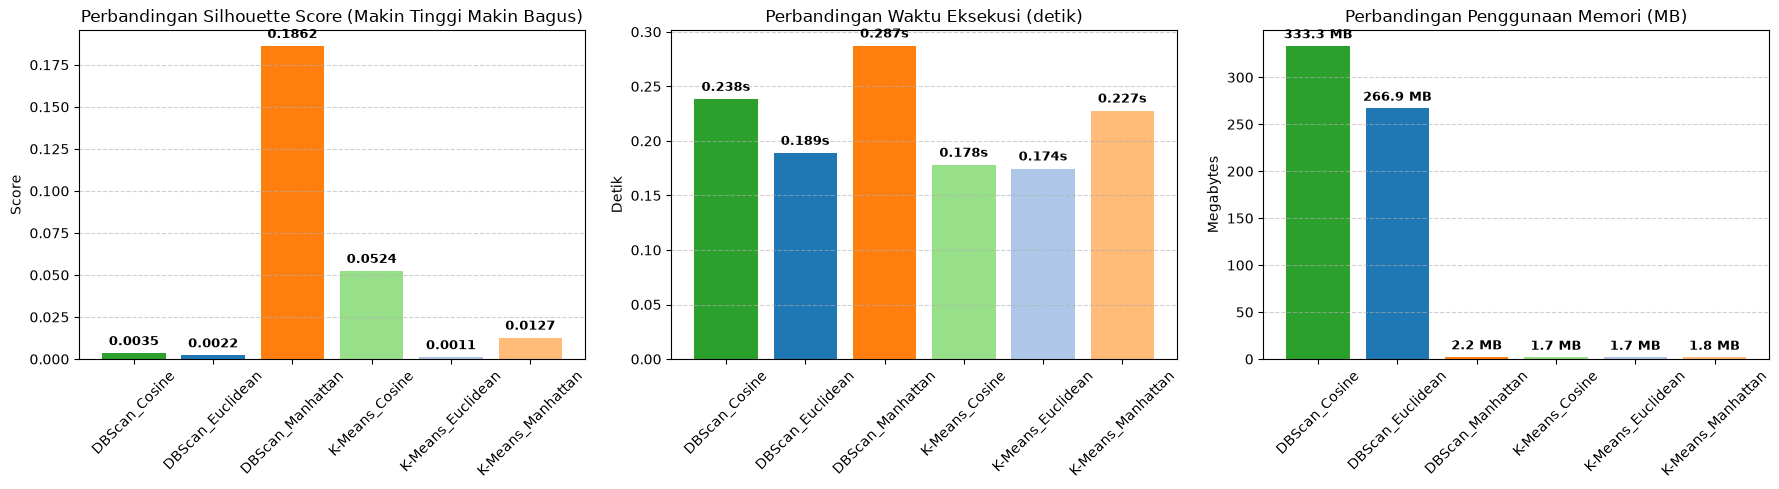

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
warna = ['#2ca02c', '#1f77b4', '#ff7f0e', '#98df8a', '#aec7e8', '#ffbb78']

bars1 = axes[0].bar(df_master['Model'], df_master['Silhouette'], color=warna)
axes[0].set_title('Perbandingan Silhouette Score (Makin Tinggi Makin Bagus)')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
for bar in bars1:
  yval = bar.get_height()
  axes[0].text(
      bar.get_x() + bar.get_width() / 2,
      yval + 0.003,
      f'{yval:.4f}',
      ha='center',
      va='bottom',
      fontsize=9,
      fontweight='bold',
  )

bars2 = axes[1].bar(df_master['Model'], df_master['Waktu (s)'], color=warna)
axes[1].set_title('Perbandingan Waktu Eksekusi (detik)')
axes[1].set_ylabel('Detik')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
for bar in bars2:
  yval = bar.get_height()
  axes[1].text(
      bar.get_x() + bar.get_width() / 2,
      yval + 0.005,
      f'{yval:.3f}s',
      ha='center',
      va='bottom',
      fontsize=9,
      fontweight='bold',
  )

bars3 = axes[2].bar(df_master['Model'], df_master['Memori (MB)'], color=warna)
axes[2].set_title('Perbandingan Penggunaan Memori (MB)')
axes[2].set_ylabel('Megabytes')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', linestyle='--', alpha=0.6)
for bar in bars3:
  yval = bar.get_height()
  axes[2].text(
      bar.get_x() + bar.get_width() / 2,
      yval + 5,
      f'{yval:.1f} MB',
      ha='center',
      va='bottom',
      fontsize=9,
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

Untuk kategorisasi berita hoaks secara menyeluruh, K-Means Cosine
adalah yang paling optimal dan efisien, sedangkan jika tujuannya menyaring hoaks berantai yang spesifik dan membuang berita anomali, DBSCAN Manhattan adalah pilihan yang paling selektif."